# 12 — Limit ladder vs market entry (why maker loses here)

Idea tested: instead of market-shorting at each trigger (taker, 0.055%), place a
ladder of SELL-LIMIT orders above the price (maker, ~0.02%, 3x cheaper) — they
fill as the pump rises into them, averaging closer to the peak.

Result: it **loses** (+1.21% market → −0.30% limit), and the breakdown shows
exactly why — **adverse selection**. For a mean-reversion entry, resting limits
fill when you DON'T want them to.

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

d = np.load('_out/limit_ab_2025.npz')
mkt, lim, fillf, runup = d['mkt'], d['lim'], d['fillf'], d['runup']
print(f'events: {len(mkt)}  (2025, time-exit 4h, no stop — clean A/B)')
print(f'MARKET (taker scale-in): {mkt.mean()*100:+.2f}%  win {(mkt>0).mean()*100:.0f}%')
print(f'LIMIT  (maker ladder)  : {lim.mean()*100:+.2f}%  win {(lim>0).mean()*100:.0f}%')

events: 2134  (2025, time-exit 4h, no stop — clean A/B)
MARKET (taker scale-in): +1.21%  win 63%
LIMIT  (maker ladder)  : -0.30%  win 55%


[saved] notebooks\pump\_out\12_limit_adverse_selection.png


WindowsPath('C:/projects/researchlab/notebooks/pump/_out/12_limit_adverse_selection.png')

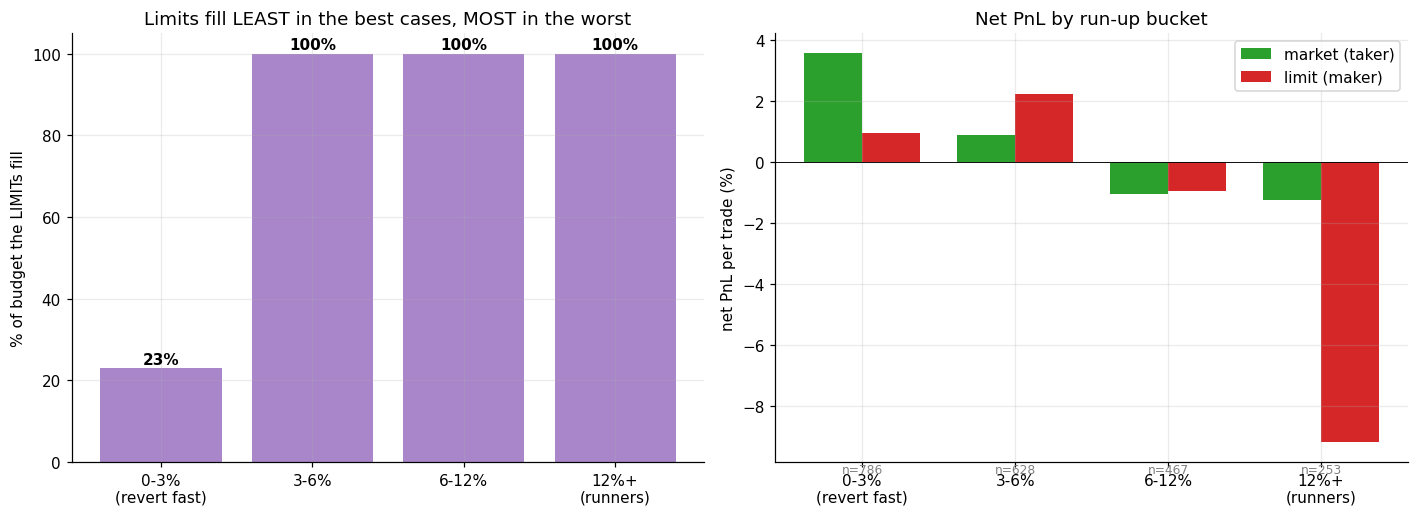

In [2]:
# breakdown by how far the pump ran up after the first trigger
buckets = [(0,0.03),(0.03,0.06),(0.06,0.12),(0.12,10)]
lab = ['0-3%\n(revert fast)','3-6%','6-12%','12%+\n(runners)']
fill_pct, lim_pnl, mkt_pnl, ns = [], [], [], []
for lo,hi in buckets:
    m=(runup>=lo)&(runup<hi)
    fill_pct.append(fillf[m].mean()*100); lim_pnl.append(lim[m].mean()*100)
    mkt_pnl.append(mkt[m].mean()*100); ns.append(int(m.sum()))

x=np.arange(len(buckets))
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.8))
a1.bar(x, fill_pct, color='tab:purple', alpha=0.8)
a1.set_xticks(x); a1.set_xticklabels(lab); a1.set_ylabel('% of budget the LIMITs fill')
a1.set_title('Limits fill LEAST in the best cases, MOST in the worst')
for i,v in enumerate(fill_pct): a1.text(i,v+1,f'{v:.0f}%',ha='center',fontsize=10,fontweight='bold')
w=0.38
a2.bar(x-w/2, mkt_pnl, w, label='market (taker)', color='tab:green')
a2.bar(x+w/2, lim_pnl, w, label='limit (maker)', color='tab:red')
a2.axhline(0,color='k',lw=0.6); a2.set_xticks(x); a2.set_xticklabels(lab)
a2.set_ylabel('net PnL per trade (%)'); a2.set_title('Net PnL by run-up bucket')
a2.legend()
for i in range(len(x)):
    a2.text(i, -10.2, f'n={ns[i]}', ha='center', fontsize=8, color='gray')
show('12_limit_adverse_selection')

## The lesson

A resting SELL-LIMIT above the market only fills **if price rises into it**.

- **Small pumps that revert fast (0-3% run-up)** — our BEST trades — the price
  never climbs to the higher rungs, so the limits fill only **23%** of budget.
  We capture +0.94% instead of the +3.59% a market order grabs. We under-bet the
  winners.
- **Mega-runners (12%+ run-up)** — our WORST trades — price blows through every
  rung, the ladder fills **100%** at high prices, and we lose **−9.21%** (vs
  −1.25% for market). We over-bet the losers.

This is **adverse selection**: for a mean-reversion (fade) entry, a passive limit
fills exactly when the move is continuing against you. The 3x fee saving is
irrelevant next to the wrong fill distribution.

**Principle:** fade/mean-reversion entries want TAKER (pay to get in NOW, before
it reverts). Momentum/breakout entries want MAKER (get filled on the pullback).
Our edge is a fade → the taker fee is the *price of avoiding adverse selection*,
and it's worth paying.

**Where to spend effort instead:** not the order TYPE but the entry TIMING —
i.e. detect exhaustion (the real top) to enter higher. That's the CVD direction.